In [1]:

# --- 1. Imports ---
import pandas as pd
from sklearn.linear_model import LinearRegression
import joblib
import matplotlib.pyplot as plt

In [2]:

# --- 2. Extract (dummy data) ---
def fetch_youtube_data():
    data = {
        "videoId": [f"vid{i:03}" for i in range(1, 21)],
        "title": [f"Video {i}" for i in range(1, 21)],
        "snippet.publishedAt": pd.date_range("2024-01-01", periods=20, freq="7D"),
        "statistics.viewCount": [1000 + i*200 for i in range(1, 21)],
        "statistics.likeCount": [50 + i*15 for i in range(1, 21)],
        "statistics.commentCount": [10 + i*5 for i in range(1, 21)],
    }
    return pd.DataFrame(data)

df_raw = fetch_youtube_data()
df_raw.head()

,videoId,title,snippet.publishedAt,statistics.viewCount,statistics.likeCount,statistics.commentCount
0,vid001,Video 1,2024-01-01,1200,65,15
1,vid002,Video 2,2024-01-08,1400,80,20
2,vid003,Video 3,2024-01-15,1600,95,25
3,vid004,Video 4,2024-01-22,1800,110,30
4,vid005,Video 5,2024-01-29,2000,125,35


In [3]:
# --- 3. Transform ---
df_raw["snippet.publishedAt"] = pd.to_datetime(df_raw["snippet.publishedAt"])
df_raw.dropna(inplace=True)

df_raw.to_csv("../data/processed/youtube_data.csv", index=False)
print("Processed data saved to ../data/processed/youtube_data.csv")

df_raw.head()


Processed data saved to ../data/processed/youtube_data.csv


,videoId,title,snippet.publishedAt,statistics.viewCount,statistics.likeCount,statistics.commentCount
0,vid001,Video 1,2024-01-01,1200,65,15
1,vid002,Video 2,2024-01-08,1400,80,20
2,vid003,Video 3,2024-01-15,1600,95,25
3,vid004,Video 4,2024-01-22,1800,110,30
4,vid005,Video 5,2024-01-29,2000,125,35


In [4]:
# --- 4. Train ---
X = df_raw[["statistics.viewCount", "statistics.likeCount", "statistics.commentCount"]]
y = df_raw["statistics.viewCount"]  # dummy target

model = LinearRegression()
model.fit(X, y)

joblib.dump(model, "../models/youtube_model.pkl")
print("Model saved to ../models/youtube_model.pkl")


Model saved to ../models/youtube_model.pkl


In [5]:
# --- 5. Predict ---
model = joblib.load("../models/youtube_model.pkl")
preds = model.predict(X)

df_raw["predicted_views"] = preds
df_raw.head()


,videoId,title,snippet.publishedAt,statistics.viewCount,statistics.likeCount,statistics.commentCount,predicted_views
0,vid001,Video 1,2024-01-01,1200,65,15,1200.0
1,vid002,Video 2,2024-01-08,1400,80,20,1400.0
2,vid003,Video 3,2024-01-15,1600,95,25,1600.0
3,vid004,Video 4,2024-01-22,1800,110,30,1800.0
4,vid005,Video 5,2024-01-29,2000,125,35,2000.0


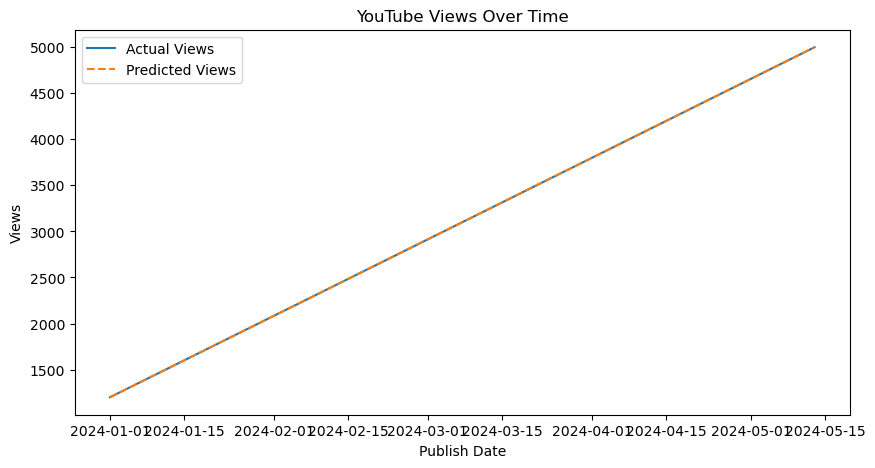

In [6]:
# --- 6. Visualize ---
plt.figure(figsize=(10,5))
plt.plot(df_raw["snippet.publishedAt"], df_raw["statistics.viewCount"], label="Actual Views")
plt.plot(df_raw["snippet.publishedAt"], df_raw["predicted_views"], label="Predicted Views", linestyle="--")
plt.xlabel("Publish Date")
plt.ylabel("Views")
plt.title("YouTube Views Over Time")
plt.legend()
plt.show()
